数据读取完成
原始数据维度：(1337, 166)
阈值：0.231，即 23.1%

识别到社区标识字段：name

TCC_b90m数据检查：
最小值：0.0392
中位数：0.2098
最大值：0.5798

1. TCC_b90m低于23.1%的社区
具有有效TCC_b90m的社区数：1337
TCC_b90m < 23.1%的社区数：807
占有效社区的比例：60.36%

前20个低树冠社区：
     name  TCC_b90m  TCC_b90m_percent  Canopy_gap_to_23.1_percent_points  Priority_rank_by_canopy_deficit
   世贸国际公寓  0.039157          3.915741                          19.184259                                1
     捷强花园  0.046161          4.616118                          18.483882                                2
大红门西里19号院  0.050454          5.045384                          18.054616                                3
  马连道欣园小区  0.063647          6.364735                          16.735265                                4
     新怡家园  0.064168          6.416801                          16.683199                                5
挂甲屯教养局1号院  0.064527          6.452656                          16.647344                                6
     嘉华世纪  0.066126          6.612601                

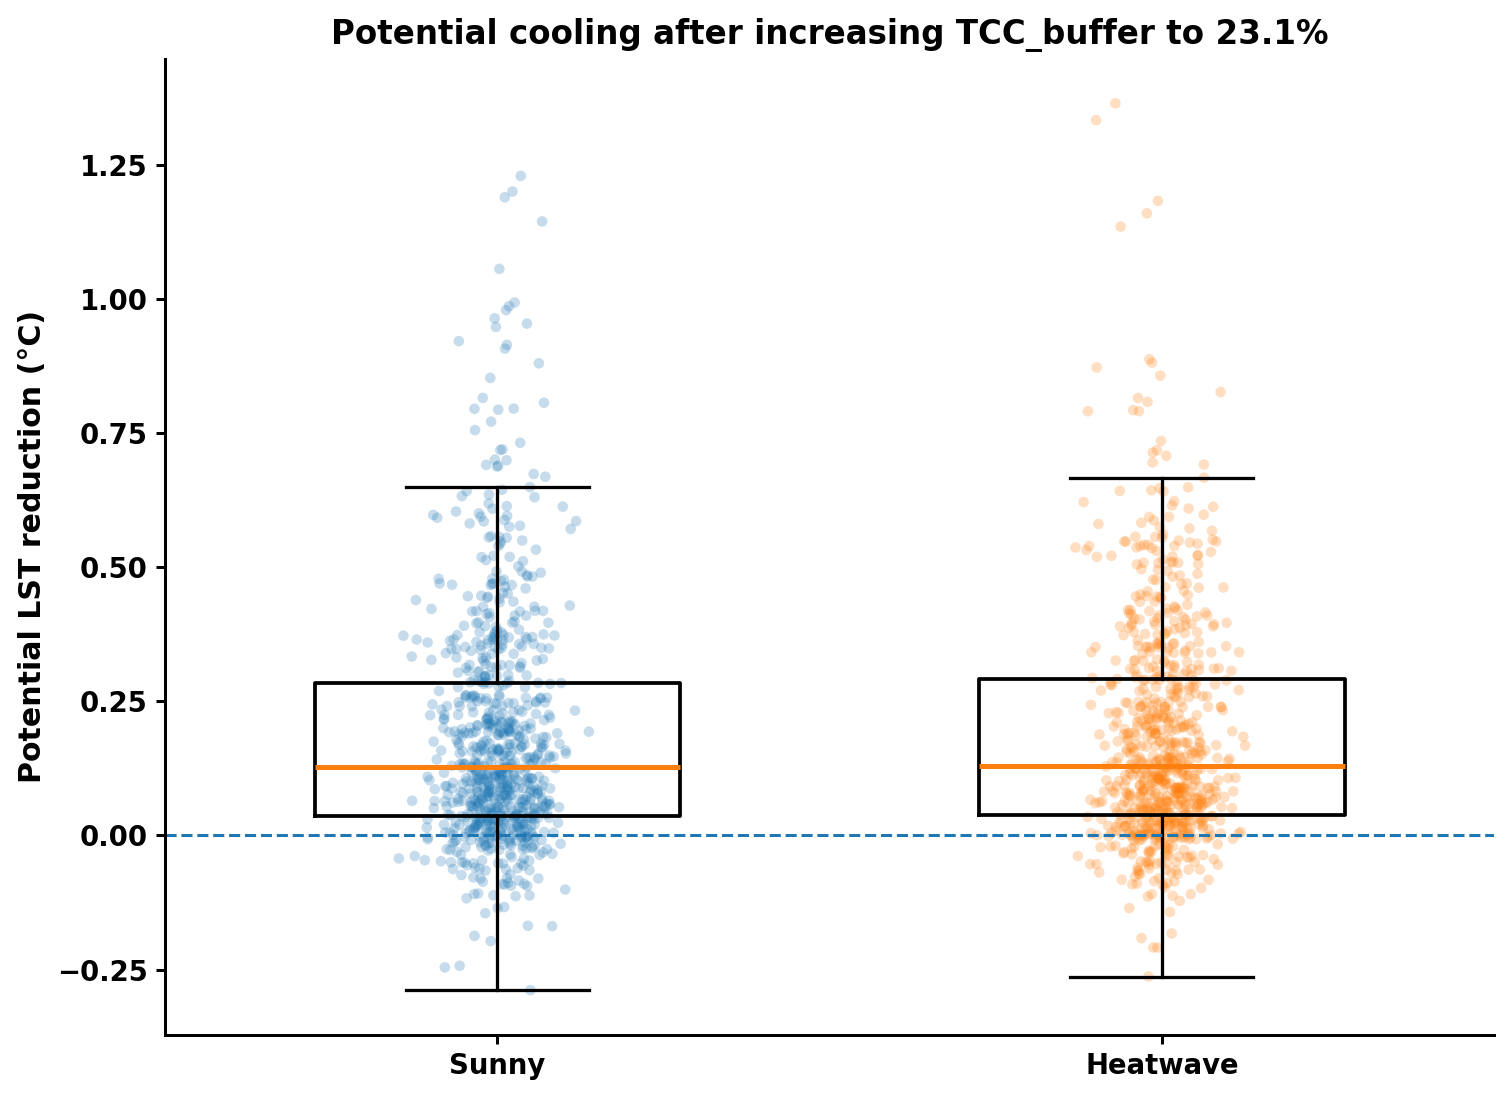


全部分析完成

Excel结果：E:\excel\FILES\博士申请\第二篇论文\脚本\Python\threshold_scenario\RF_TCC_b90m_23.1_percent_scenario_results.xlsx
社区比较CSV：E:\excel\FILES\博士申请\第二篇论文\脚本\Python\threshold_scenario\RF_TCC_threshold_community_comparison.csv
模型汇总CSV：E:\excel\FILES\博士申请\第二篇论文\脚本\Python\threshold_scenario\RF_TCC_threshold_model_summary.csv
降温对比图：E:\excel\FILES\博士申请\第二篇论文\脚本\Python\threshold_scenario\RF_TCC_threshold_cooling_comparison.png

模型与情景汇总：
 Weather  Model_Sample_Size  Intervention_Community_Count  RF_Full_Fit_R2  RF_Full_Fit_RMSE  RF_OOB_R2  Mean_Current_Predicted_LST  Mean_Scenario_Predicted_LST  Mean_Cooling_Intervention_Communities  Median_Cooling_Intervention_Communities  Minimum_Cooling_Intervention_Communities  Maximum_Cooling_Intervention_Communities  Cooling_SD_Intervention_Communities  Communities_Cooling_Above_0C  Communities_Cooling_Above_0.5C  Communities_Cooling_Above_1.0C  Communities_With_Predicted_Warming
   SUNNY               1337                           807        0.950175   

In [1]:
# =============================================================================
# RF阈值情景模拟：
# 1. 筛选TCC_b90m < 23.1%的社区
# 2. 预测当前SUNNY与HEATWAVE条件下的LST
# 3. 将低于阈值社区的TCC_b90m提升至23.1%
# 4. 预测情景LST并计算潜在降温量
# =============================================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")


# =============================================================================
# 1. 路径设置
# =============================================================================
DATA_PATH = Path(
    r"E:\excel\FILES\博士申请\第二篇论文\data\wuhuanshiliang\SH_attributes.xls"
)

OUTPUT_DIR = Path(
    r"E:\excel\FILES\博士申请\第二篇论文\脚本\Python\threshold_scenario"
)

# 前面RF调参输出的最佳参数
BEST_PARAMS_PATH = Path(
    r"E:\excel\FILES\博士申请\第二篇论文\脚本\Python\importance"
    r"\RF_best_parameters.csv"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# =============================================================================
# 2. 核心参数
# =============================================================================

# 23.1%以0—1比例表示
TCC_THRESHOLD = 0.231

TCC_VARIABLE = "TCC_b90m"

TARGETS = [
    "SUNNY",
    "HEATWAVE",
]

TARGET_LABEL_MAP = {
    "SUNNY": "Sunny",
    "HEATWAVE": "Heatwave",
}

RANDOM_STATE = 123


# =============================================================================
# 3. RF自变量
#    与原SUNNY和HEATWAVE模型保持一致
# =============================================================================
INDEPENDENT_VARS = [
    "TCC",
    "GCI",
    "BCI",
    "WCI",
    "RCI",
    "Shape_Area",
    "jungong",
    "BAH",
    "BHSD",
    "DIST",
    "TCC_b90m",
    "GCI_b90m",
    "BCI_b90m",
    "WCI_b90m",
    "RCI_b90m",
    "BAH_b90m",
    "BHSD_b90m",
]


# =============================================================================
# 4. 社区标识字段
#
# 脚本会按照下列顺序自动查找。
# 请把你实际的社区编号或社区名称字段放到列表前面。
# =============================================================================
COMMUNITY_ID_CANDIDATES = [
    "Community_ID",
    "community_id",
    "Community",
    "community",
    "Name",
    "NAME",
    "name",
    "ID",
    "OBJECTID",
    "FID",
]


# =============================================================================
# 5. 辅助函数
# =============================================================================
def detect_community_id_column(
    data: pd.DataFrame,
):
    """
    自动识别社区名称或编号字段。

    如果没有找到，则使用原始数据行号作为社区ID。
    """

    for column in COMMUNITY_ID_CANDIDATES:
        if column in data.columns:
            return column

    return None


def read_best_parameters(
    parameter_table: pd.DataFrame,
    target: str,
):
    """
    从RF_best_parameters.csv中读取指定模型的最佳参数。

    需要包含字段：
    LST
    ntree
    mtry
    min.node.size
    """

    required_parameter_columns = [
        "LST",
        "ntree",
        "mtry",
        "min.node.size",
    ]

    missing = [
        column
        for column in required_parameter_columns
        if column not in parameter_table.columns
    ]

    if missing:
        raise KeyError(
            "最佳参数文件缺少以下字段：\n"
            + "\n".join(missing)
        )

    row = parameter_table.loc[
        parameter_table["LST"].astype(str).str.upper()
        == target.upper()
    ]

    if row.empty:
        raise ValueError(
            f"最佳参数文件中找不到 {target} 模型。"
        )

    row = row.iloc[0]

    return {
        "n_estimators": int(row["ntree"]),
        "max_features": int(row["mtry"]),
        "min_samples_leaf": int(
            row["min.node.size"]
        ),
    }


def calculate_rmse(
    observed,
    predicted,
):
    """计算RMSE。"""

    return float(
        np.sqrt(
            mean_squared_error(
                observed,
                predicted,
            )
        )
    )


def build_rf_model(
    parameters: dict,
):
    """根据最佳参数建立随机森林模型。"""

    return RandomForestRegressor(
        n_estimators=parameters[
            "n_estimators"
        ],
        max_features=parameters[
            "max_features"
        ],
        min_samples_leaf=parameters[
            "min_samples_leaf"
        ],
        bootstrap=True,

        # 用于输出OOB R²
        oob_score=True,

        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def classify_cooling(
    cooling_value: float,
):
    """
    根据预测降温量分类。

    注意：这是模型情景结果分类，
    不是统计显著性分类。
    """

    if pd.isna(cooling_value):
        return np.nan

    if cooling_value < 0:
        return "Predicted warming"

    if cooling_value < 0.25:
        return "Cooling < 0.25°C"

    if cooling_value < 0.50:
        return "Cooling 0.25–0.50°C"

    if cooling_value < 1.00:
        return "Cooling 0.50–1.00°C"

    return "Cooling ≥ 1.00°C"


# =============================================================================
# 6. 读取数据
# =============================================================================
df = pd.read_excel(
    DATA_PATH,
    sheet_name=0,
    engine="xlrd",
)

best_params_df = pd.read_csv(
    BEST_PARAMS_PATH,
    encoding="utf-8-sig",
)

print("=" * 80)
print("数据读取完成")
print("=" * 80)
print(f"原始数据维度：{df.shape}")
print(f"阈值：{TCC_THRESHOLD:.3f}，即 {TCC_THRESHOLD * 100:.1f}%")


# =============================================================================
# 7. 检查字段
# =============================================================================
required_columns = (
    TARGETS
    + INDEPENDENT_VARS
)

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        "原始数据缺少以下字段：\n"
        + "\n".join(missing_columns)
    )


# =============================================================================
# 8. 建立社区标识
# =============================================================================
community_id_column = (
    detect_community_id_column(df)
)

if community_id_column is None:

    df["Community_ID_Output"] = (
        df.index + 1
    )

    community_id_column = (
        "Community_ID_Output"
    )

    print(
        "\n未识别到社区编号或名称字段，"
        "已使用原始数据行号作为Community_ID_Output。"
    )

else:

    print(
        f"\n识别到社区标识字段："
        f"{community_id_column}"
    )


# =============================================================================
# 9. 将参与计算的变量转换为数值
# =============================================================================
numeric_columns = list(
    dict.fromkeys(
        TARGETS
        + INDEPENDENT_VARS
    )
)

for column in numeric_columns:

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )

df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True,
)

# 因变量0视为缺失
for target in TARGETS:

    df.loc[
        df[target] == 0,
        target,
    ] = np.nan


# =============================================================================
# 10. 检查TCC_b90m的数据量纲
# =============================================================================
valid_tcc = df[TCC_VARIABLE].dropna()

if valid_tcc.empty:
    raise ValueError(
        f"{TCC_VARIABLE}全部为缺失值。"
    )

tcc_max = valid_tcc.max()
tcc_median = valid_tcc.median()

print("\nTCC_b90m数据检查：")
print(f"最小值：{valid_tcc.min():.4f}")
print(f"中位数：{tcc_median:.4f}")
print(f"最大值：{tcc_max:.4f}")

if tcc_max > 1.5:
    raise ValueError(
        "\n当前TCC_b90m似乎采用0—100的百分数形式，"
        "但脚本阈值设置为0.231。\n"
        "请确认数据量纲。若数据值为23.1而不是0.231，"
        "请将TCC_THRESHOLD改为23.1。"
    )


# =============================================================================
# 11. 筛选TCC_b90m低于23.1%的所有社区
# =============================================================================
low_tcc_mask = (
    df[TCC_VARIABLE].notna()
    & (
        df[TCC_VARIABLE]
        < TCC_THRESHOLD
    )
)

low_tcc_communities = (
    df.loc[
        low_tcc_mask,
        [
            community_id_column,
            TCC_VARIABLE,
        ],
    ]
    .copy()
)

low_tcc_communities[
    "TCC_b90m_percent"
] = (
    low_tcc_communities[
        TCC_VARIABLE
    ]
    * 100
)

low_tcc_communities[
    "Canopy_gap_to_23.1_percent_points"
] = (
    (
        TCC_THRESHOLD
        - low_tcc_communities[
            TCC_VARIABLE
        ]
    )
    * 100
)

low_tcc_communities = (
    low_tcc_communities
    .sort_values(
        TCC_VARIABLE,
        ascending=True,
    )
    .reset_index(drop=True)
)

low_tcc_communities[
    "Priority_rank_by_canopy_deficit"
] = (
    np.arange(
        1,
        len(low_tcc_communities) + 1,
    )
)

print("\n" + "=" * 80)
print("1. TCC_b90m低于23.1%的社区")
print("=" * 80)

print(
    f"具有有效TCC_b90m的社区数："
    f"{valid_tcc.shape[0]}"
)

print(
    f"TCC_b90m < 23.1%的社区数："
    f"{len(low_tcc_communities)}"
)

print(
    f"占有效社区的比例："
    f"{len(low_tcc_communities) / len(valid_tcc) * 100:.2f}%"
)

print("\n前20个低树冠社区：")

print(
    low_tcc_communities
    .head(20)
    .to_string(index=False)
)


# =============================================================================
# 12. 分别建立SUNNY和HEATWAVE模型并进行情景预测
# =============================================================================
scenario_results = {}
model_evaluation_rows = []

for target in TARGETS:

    print("\n" + "=" * 80)
    print(
        f"RF模型与阈值情景模拟：{target}"
    )
    print("=" * 80)

    # -------------------------------------------------------------------------
    # 12.1 只保留当前模型需要的完整案例
    # -------------------------------------------------------------------------
    model_columns = (
        [community_id_column, target]
        + INDEPENDENT_VARS
    )

    model_data = df[
        model_columns
    ].copy()

    model_data = model_data.dropna(
        subset=[target] + INDEPENDENT_VARS
    ).copy()

    if model_data.empty:
        raise ValueError(
            f"{target}模型没有完整案例。"
        )

    X_current = model_data[
        INDEPENDENT_VARS
    ].copy()

    y = model_data[
        target
    ].astype(float).copy()

    # -------------------------------------------------------------------------
    # 12.2 读取最佳参数
    # -------------------------------------------------------------------------
    best_parameters = (
        read_best_parameters(
            best_params_df,
            target,
        )
    )

    print(f"有效样本数：{len(model_data)}")
    print(
        f"ntree："
        f"{best_parameters['n_estimators']}"
    )
    print(
        f"mtry："
        f"{best_parameters['max_features']}"
    )
    print(
        f"min.node.size："
        f"{best_parameters['min_samples_leaf']}"
    )

    # -------------------------------------------------------------------------
    # 12.3 使用全部完整案例拟合最终解释/情景模型
    # -------------------------------------------------------------------------
    rf_model = build_rf_model(
        best_parameters
    )

    rf_model.fit(
        X_current,
        y,
    )

    # -------------------------------------------------------------------------
    # 12.4 当前条件下预测LST
    # -------------------------------------------------------------------------
    current_prediction = (
        rf_model.predict(
            X_current
        )
    )

    # -------------------------------------------------------------------------
    # 12.5 创建阈值情景
    #
    # 仅修改TCC_b90m < 0.231的社区；
    # 其他社区和其他变量保持不变。
    # -------------------------------------------------------------------------
    X_scenario = X_current.copy()

    intervention_mask = (
        X_scenario[TCC_VARIABLE]
        < TCC_THRESHOLD
    )

    original_tcc = (
        X_scenario[
            TCC_VARIABLE
        ].copy()
    )

    X_scenario.loc[
        intervention_mask,
        TCC_VARIABLE,
    ] = TCC_THRESHOLD

    # -------------------------------------------------------------------------
    # 12.6 阈值情景下预测LST
    # -------------------------------------------------------------------------
    scenario_prediction = (
        rf_model.predict(
            X_scenario
        )
    )

    # -------------------------------------------------------------------------
    # 12.7 计算潜在降温量
    #
    # 正值：情景LST低于当前LST，即预测降温
    # 负值：情景LST高于当前LST，即预测升温
    # -------------------------------------------------------------------------
    cooling_benefit = (
        current_prediction
        - scenario_prediction
    )

    # -------------------------------------------------------------------------
    # 12.8 保存社区级结果
    # -------------------------------------------------------------------------
    result = pd.DataFrame(
        {
            "Community_ID": model_data[
                community_id_column
            ].to_numpy(),

            "Weather": target,

            "Observed_LST": (
                y.to_numpy()
            ),

            "Predicted_LST_Current": (
                current_prediction
            ),

            "TCC_b90m_Current": (
                original_tcc.to_numpy()
            ),

            "TCC_b90m_Current_Percent": (
                original_tcc.to_numpy()
                * 100
            ),

            "Below_23.1_Percent": (
                intervention_mask.to_numpy()
            ),

            "TCC_b90m_Scenario": (
                X_scenario[
                    TCC_VARIABLE
                ].to_numpy()
            ),

            "TCC_b90m_Scenario_Percent": (
                X_scenario[
                    TCC_VARIABLE
                ].to_numpy()
                * 100
            ),

            "Canopy_Increase_Percentage_Points": (
                (
                    X_scenario[
                        TCC_VARIABLE
                    ].to_numpy()
                    - original_tcc.to_numpy()
                )
                * 100
            ),

            "Predicted_LST_After_Threshold": (
                scenario_prediction
            ),

            "Potential_Cooling_Delta_LST": (
                cooling_benefit
            ),
        }
    )

    result[
        "Cooling_Classification"
    ] = result[
        "Potential_Cooling_Delta_LST"
    ].apply(
        classify_cooling
    )

    # 对干预社区按照降温潜力排序
    result[
        "Cooling_Priority_Rank"
    ] = np.nan

    intervention_indices = result.loc[
        result["Below_23.1_Percent"],
        "Potential_Cooling_Delta_LST",
    ].sort_values(
        ascending=False
    ).index

    result.loc[
        intervention_indices,
        "Cooling_Priority_Rank",
    ] = np.arange(
        1,
        len(intervention_indices) + 1,
    )

    scenario_results[target] = result

    # -------------------------------------------------------------------------
    # 12.9 模型诊断
    #
    # Full-fit R²是训练拟合度，不代表泛化能力；
    # OOB R²更适合在此处作为模型性能参考。
    # -------------------------------------------------------------------------
    full_fit_r2 = r2_score(
        y,
        current_prediction,
    )

    full_fit_rmse = calculate_rmse(
        y,
        current_prediction,
    )

    oob_r2 = getattr(
        rf_model,
        "oob_score_",
        np.nan,
    )

    # -------------------------------------------------------------------------
    # 12.10 统计低阈值社区的情景结果
    # -------------------------------------------------------------------------
    intervention_result = (
        result.loc[
            result[
                "Below_23.1_Percent"
            ]
        ].copy()
    )

    cooling_series = (
        intervention_result[
            "Potential_Cooling_Delta_LST"
        ]
    )

    model_evaluation_rows.append(
        {
            "Weather": target,
            "Model_Sample_Size": len(
                result
            ),
            "Intervention_Community_Count": len(
                intervention_result
            ),
            "RF_Full_Fit_R2": full_fit_r2,
            "RF_Full_Fit_RMSE": full_fit_rmse,
            "RF_OOB_R2": oob_r2,
            "Mean_Current_Predicted_LST": result[
                "Predicted_LST_Current"
            ].mean(),
            "Mean_Scenario_Predicted_LST": result[
                "Predicted_LST_After_Threshold"
            ].mean(),
            "Mean_Cooling_Intervention_Communities": cooling_series.mean(),
            "Median_Cooling_Intervention_Communities": cooling_series.median(),
            "Minimum_Cooling_Intervention_Communities": cooling_series.min(),
            "Maximum_Cooling_Intervention_Communities": cooling_series.max(),
            "Cooling_SD_Intervention_Communities": cooling_series.std(),
            "Communities_Cooling_Above_0C": int(
                (
                    cooling_series > 0
                ).sum()
            ),
            "Communities_Cooling_Above_0.5C": int(
                (
                    cooling_series >= 0.5
                ).sum()
            ),
            "Communities_Cooling_Above_1.0C": int(
                (
                    cooling_series >= 1.0
                ).sum()
            ),
            "Communities_With_Predicted_Warming": int(
                (
                    cooling_series < 0
                ).sum()
            ),
        }
    )

    print(
        f"\nFull-fit R²："
        f"{full_fit_r2:.4f}"
    )

    print(
        f"Full-fit RMSE："
        f"{full_fit_rmse:.4f} °C"
    )

    print(
        f"OOB R²："
        f"{oob_r2:.4f}"
    )

    print(
        f"\n参与阈值情景的社区数："
        f"{len(intervention_result)}"
    )

    print(
        f"平均潜在降温："
        f"{cooling_series.mean():.4f} °C"
    )

    print(
        f"中位潜在降温："
        f"{cooling_series.median():.4f} °C"
    )

    print(
        f"最大潜在降温："
        f"{cooling_series.max():.4f} °C"
    )

    print(
        f"最小潜在降温："
        f"{cooling_series.min():.4f} °C"
    )

    print("\n潜在降温最高的20个社区：")

    top_20 = (
        intervention_result
        .sort_values(
            "Potential_Cooling_Delta_LST",
            ascending=False,
        )
        .head(20)
    )

    print(
        top_20[
            [
                "Community_ID",
                "TCC_b90m_Current_Percent",
                "Canopy_Increase_Percentage_Points",
                "Predicted_LST_Current",
                "Predicted_LST_After_Threshold",
                "Potential_Cooling_Delta_LST",
                "Cooling_Priority_Rank",
            ]
        ].to_string(
            index=False
        )
    )


# =============================================================================
# 13. 合并晴天和热浪结果
# =============================================================================
all_scenario_results = pd.concat(
    [
        scenario_results[target]
        for target in TARGETS
    ],
    ignore_index=True,
)

model_summary = pd.DataFrame(
    model_evaluation_rows
)


# =============================================================================
# 14. 将晴天和热浪结果合并为每个社区一行
# =============================================================================
sunny_selected = (
    scenario_results["SUNNY"][
        [
            "Community_ID",
            "Observed_LST",
            "Predicted_LST_Current",
            "Predicted_LST_After_Threshold",
            "Potential_Cooling_Delta_LST",
            "Cooling_Priority_Rank",
        ]
    ]
    .rename(
        columns={
            "Observed_LST":
                "Observed_LST_Sunny",

            "Predicted_LST_Current":
                "Predicted_LST_Current_Sunny",

            "Predicted_LST_After_Threshold":
                "Predicted_LST_Threshold_Sunny",

            "Potential_Cooling_Delta_LST":
                "Potential_Cooling_Sunny",

            "Cooling_Priority_Rank":
                "Cooling_Priority_Rank_Sunny",
        }
    )
)

heatwave_selected = (
    scenario_results["HEATWAVE"][
        [
            "Community_ID",
            "Observed_LST",
            "Predicted_LST_Current",
            "Predicted_LST_After_Threshold",
            "Potential_Cooling_Delta_LST",
            "Cooling_Priority_Rank",
        ]
    ]
    .rename(
        columns={
            "Observed_LST":
                "Observed_LST_Heatwave",

            "Predicted_LST_Current":
                "Predicted_LST_Current_Heatwave",

            "Predicted_LST_After_Threshold":
                "Predicted_LST_Threshold_Heatwave",

            "Potential_Cooling_Delta_LST":
                "Potential_Cooling_Heatwave",

            "Cooling_Priority_Rank":
                "Cooling_Priority_Rank_Heatwave",
        }
    )
)

community_comparison = pd.merge(
    low_tcc_communities.rename(
        columns={
            community_id_column:
                "Community_ID"
        }
    ),
    sunny_selected,
    on="Community_ID",
    how="left",
)

community_comparison = pd.merge(
    community_comparison,
    heatwave_selected,
    on="Community_ID",
    how="left",
)

# 两种天气平均潜在降温
community_comparison[
    "Mean_Potential_Cooling"
] = community_comparison[
    [
        "Potential_Cooling_Sunny",
        "Potential_Cooling_Heatwave",
    ]
].mean(
    axis=1,
    skipna=True,
)

# 两种天气中的最低潜在降温：
# 可作为相对保守的优先级指标
community_comparison[
    "Minimum_Potential_Cooling_Across_Weather"
] = community_comparison[
    [
        "Potential_Cooling_Sunny",
        "Potential_Cooling_Heatwave",
    ]
].min(
    axis=1,
    skipna=True,
)

community_comparison = (
    community_comparison
    .sort_values(
        "Mean_Potential_Cooling",
        ascending=False,
    )
    .reset_index(drop=True)
)

community_comparison[
    "Overall_Cooling_Priority_Rank"
] = np.arange(
    1,
    len(community_comparison) + 1,
)


# =============================================================================
# 15. 输出Excel与CSV
# =============================================================================
excel_output_path = (
    OUTPUT_DIR
    / "RF_TCC_b90m_23.1_percent_scenario_results.xlsx"
)

with pd.ExcelWriter(
    excel_output_path,
    engine="openpyxl",
) as writer:

    low_tcc_communities.to_excel(
        writer,
        sheet_name="Low_TCC_Communities",
        index=False,
    )

    scenario_results[
        "SUNNY"
    ].to_excel(
        writer,
        sheet_name="Sunny_All_Results",
        index=False,
    )

    scenario_results[
        "HEATWAVE"
    ].to_excel(
        writer,
        sheet_name="Heatwave_All_Results",
        index=False,
    )

    scenario_results[
        "SUNNY"
    ].loc[
        scenario_results[
            "SUNNY"
        ][
            "Below_23.1_Percent"
        ]
    ].sort_values(
        "Potential_Cooling_Delta_LST",
        ascending=False,
    ).to_excel(
        writer,
        sheet_name="Sunny_Intervention",
        index=False,
    )

    scenario_results[
        "HEATWAVE"
    ].loc[
        scenario_results[
            "HEATWAVE"
        ][
            "Below_23.1_Percent"
        ]
    ].sort_values(
        "Potential_Cooling_Delta_LST",
        ascending=False,
    ).to_excel(
        writer,
        sheet_name="Heatwave_Intervention",
        index=False,
    )

    community_comparison.to_excel(
        writer,
        sheet_name="Weather_Comparison",
        index=False,
    )

    model_summary.to_excel(
        writer,
        sheet_name="Model_Summary",
        index=False,
    )


# 同时输出便于GIS连接的CSV
community_comparison_csv = (
    OUTPUT_DIR
    / "RF_TCC_threshold_community_comparison.csv"
)

community_comparison.to_csv(
    community_comparison_csv,
    index=False,
    encoding="utf-8-sig",
)

model_summary_csv = (
    OUTPUT_DIR
    / "RF_TCC_threshold_model_summary.csv"
)

model_summary.to_csv(
    model_summary_csv,
    index=False,
    encoding="utf-8-sig",
)


# =============================================================================
# 16. 绘制晴天与热浪潜在降温对比图
# =============================================================================
plot_data = all_scenario_results.loc[
    all_scenario_results[
        "Below_23.1_Percent"
    ]
].copy()

fig, ax = plt.subplots(
    figsize=(8.5, 6.2),
    dpi=180,
)

sunny_values = plot_data.loc[
    plot_data["Weather"] == "SUNNY",
    "Potential_Cooling_Delta_LST",
].dropna()

heatwave_values = plot_data.loc[
    plot_data["Weather"] == "HEATWAVE",
    "Potential_Cooling_Delta_LST",
].dropna()

boxplot = ax.boxplot(
    [
        sunny_values,
        heatwave_values,
    ],
    labels=[
        "Sunny",
        "Heatwave",
    ],
    widths=0.55,
    patch_artist=False,
    showfliers=False,
    medianprops={
        "linewidth": 2.0,
    },
    boxprops={
        "linewidth": 1.5,
    },
    whiskerprops={
        "linewidth": 1.3,
    },
    capprops={
        "linewidth": 1.3,
    },
)

# 添加轻微横向抖动散点
rng = np.random.default_rng(
    RANDOM_STATE
)

for position, values in enumerate(
    [
        sunny_values,
        heatwave_values,
    ],
    start=1,
):

    jitter = rng.normal(
        loc=position,
        scale=0.045,
        size=len(values),
    )

    ax.scatter(
        jitter,
        values,
        s=18,
        alpha=0.25,
        edgecolors="none",
    )

ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.2,
)

ax.set_ylabel(
    "Potential LST reduction (°C)",
    fontsize=12,
    fontweight="bold",
)

ax.set_xlabel(
    None
)

ax.set_title(
    "Potential cooling after increasing TCC_buffer to 23.1%",
    fontsize=13,
    fontweight="bold",
)

ax.tick_params(
    axis="both",
    labelsize=11,
    width=1.2,
    direction="out",
)

for tick_label in (
    ax.get_xticklabels()
    + ax.get_yticklabels()
):
    tick_label.set_fontweight(
        "bold"
    )

ax.spines["top"].set_visible(
    False
)

ax.spines["right"].set_visible(
    False
)

ax.spines["left"].set_linewidth(
    1.2
)

ax.spines["bottom"].set_linewidth(
    1.2
)

ax.grid(False)

fig.tight_layout()

plot_path = (
    OUTPUT_DIR
    / "RF_TCC_threshold_cooling_comparison.png"
)

fig.savefig(
    plot_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(fig)


# =============================================================================
# 17. 最终输出
# =============================================================================
print("\n" + "=" * 80)
print("全部分析完成")
print("=" * 80)

print(f"\nExcel结果：{excel_output_path}")
print(f"社区比较CSV：{community_comparison_csv}")
print(f"模型汇总CSV：{model_summary_csv}")
print(f"降温对比图：{plot_path}")

print("\n模型与情景汇总：")
print(
    model_summary.to_string(
        index=False
    )
)

print("\n综合潜在降温最高的20个社区：")

print(
    community_comparison[
        [
            "Community_ID",
            "TCC_b90m_percent",
            "Canopy_gap_to_23.1_percent_points",
            "Potential_Cooling_Sunny",
            "Potential_Cooling_Heatwave",
            "Mean_Potential_Cooling",
            "Overall_Cooling_Priority_Rank",
        ]
    ]
    .head(20)
    .to_string(index=False)
)